# Waste Classification with ResNet50

This notebook trains a ResNet50 transfer learning model on the merged glass waste dataset.

## Setup

### Import Necessary Libraries:

In [1]:
%pip install tensorflow seaborn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

/opt/homebrew/Caskroom/miniforge/base/envs/waste-classification/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print(tf.config.list_physical_devices())

TensorFlow version: 2.16.2
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download and explore the dataset

 This dataset has 15,150 images from 12 different classes of household garbage; paper, cardboard, biological, metal, plastic, green-glass, brown-glass, white-glass, clothes, shoes, batteries, and trash.

```garbage_classification/
├── battery/
├── biological/
├── brown-glass/
├── cardboard/
├── clothes/
├── green-glass/
├── metal/
├── paper/
├── plastic/
├── shoes/
├── trash/
└── white-glass/```


In [4]:
import kagglehub

path = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("Path to dataset files:", path)

print("Dataset folder:")
print(os.listdir(path))

Path to dataset files: /Users/thazinhtun/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1
Dataset folder:
['garbage_classification']


In [5]:
if "garbage_classification" in os.listdir(path):
    dataset_path = os.path.join(path, "garbage_classification")
else:
    dataset_path = path

print("Final dataset path:", dataset_path)

Final dataset path: /Users/thazinhtun/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1/garbage_classification


### Merge glass classes

In [6]:
import shutil

mapping = {
    'green-glass': 'glass',
    'white-glass': 'glass',
    'brown-glass': 'glass'
}

original_dataset_path = Path(path) / 'garbage_classification'
if not original_dataset_path.exists():
    original_dataset_path = Path(path)

merged_dataset_path = Path('garbage_classification_merged_glass')
merged_dataset_path.mkdir(exist_ok=True)

for class_folder in original_dataset_path.iterdir():
    if class_folder.is_dir():
        class_name = mapping.get(class_folder.name, class_folder.name)
        new_class_folder = merged_dataset_path / class_name
        new_class_folder.mkdir(exist_ok=True)

        for image_file in class_folder.iterdir():
            if image_file.is_file():
                new_image_name = f'{class_folder.name}_{image_file.name}'
                new_image_path = new_class_folder / new_image_name

                if not new_image_path.exists():
                    shutil.copy2(image_file, new_image_path)

dataset_path = str(merged_dataset_path)
print('Using 10-class dataset path:', dataset_path)


Using 10-class dataset path: garbage_classification_merged_glass


In [7]:
classes = os.listdir(dataset_path)

print("garbage_classification Classes:")
for c in classes:
    print("-", c)

garbage_classification Classes:
- paper
- clothes
- metal
- cardboard
- trash
- glass
- biological
- battery
- plastic
- shoes


### Visualize Class Distribution

paper: 1050 images
clothes: 5325 images
metal: 769 images
cardboard: 891 images
trash: 697 images
glass: 2011 images
biological: 985 images
battery: 945 images
plastic: 865 images
shoes: 1977 images


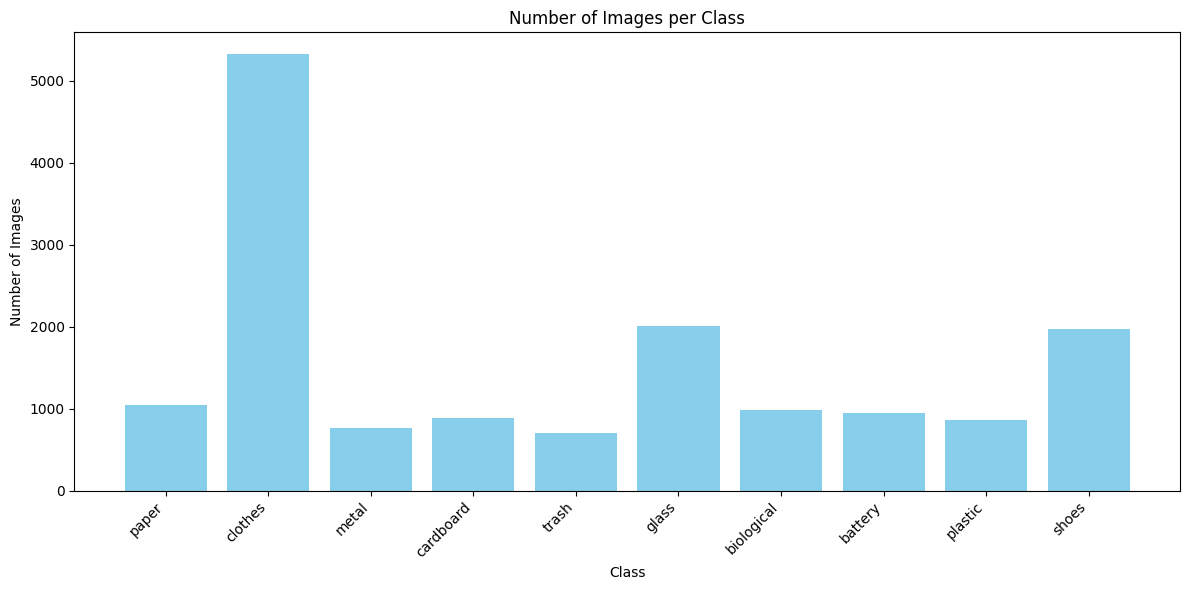

In [8]:
class_counts = {}

for c in classes:
    folder_path = os.path.join(dataset_path, c)

    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        class_counts[c] = count
        print(f"{c}: {count} images")

plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color="skyblue")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Vasualize Images

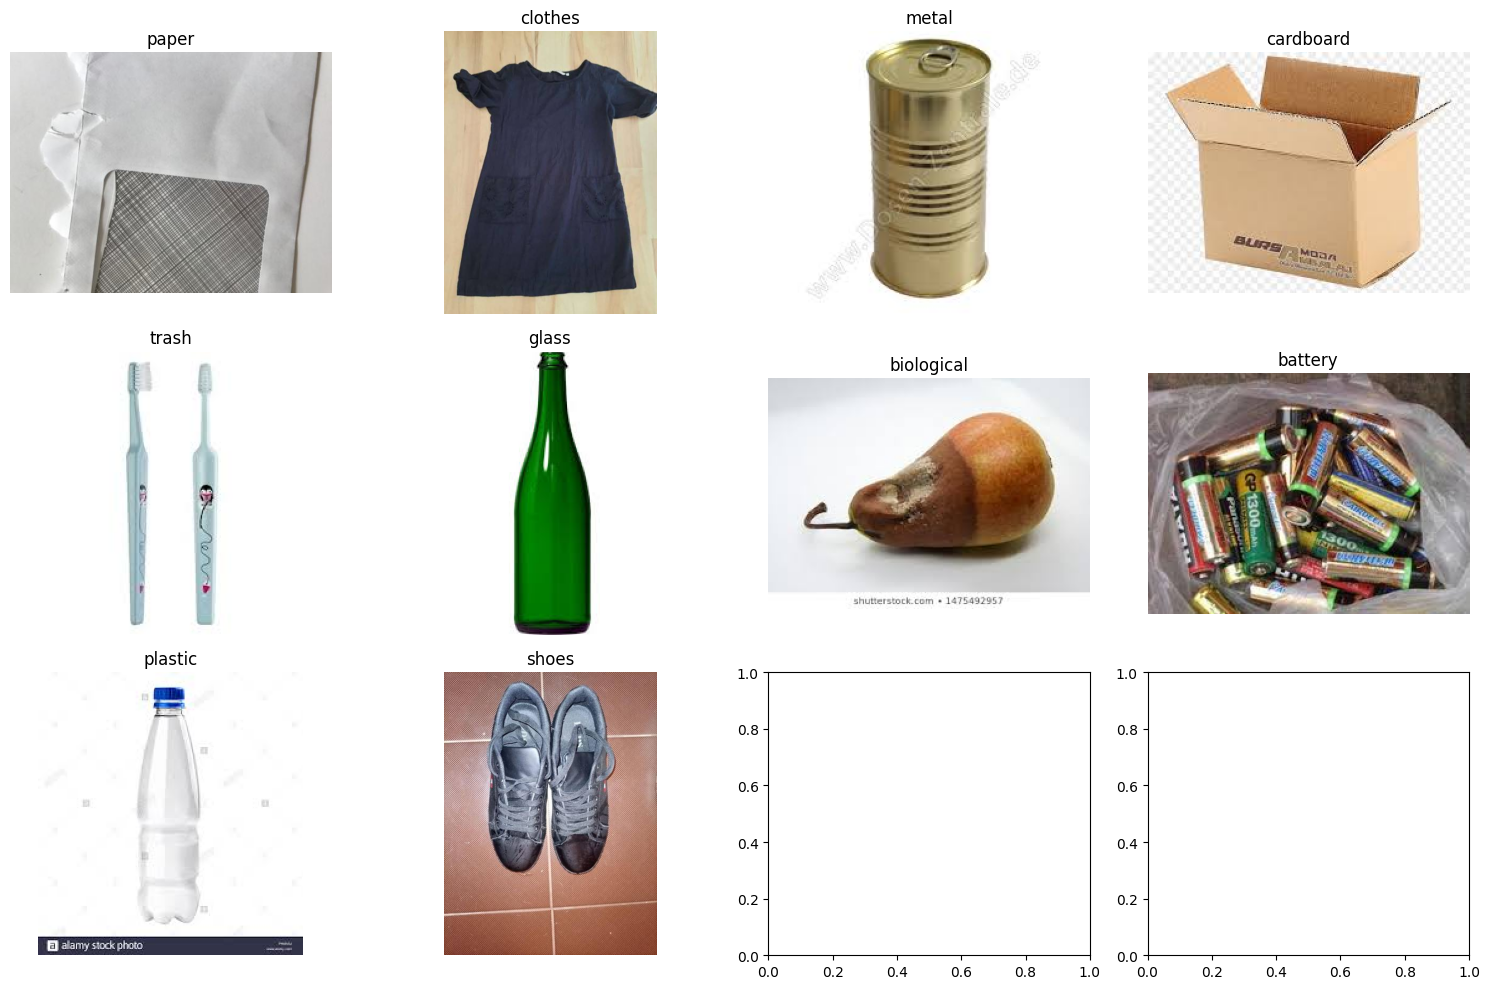

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

classes_path = [p for p in Path(dataset_path).iterdir() if p.is_dir()]

i = 0

for folder in classes_path:

    images = list(folder.glob("*.*"))

    if len(images) == 0:
        continue

    img_path = random.choice(images)
    img = tf.keras.utils.load_img(img_path)

    axes[i].imshow(img)
    axes[i].set_title(folder.name)
    axes[i].axis("off")

    i += 1

plt.tight_layout()
plt.show()

## Create Dataset

### Define some parameters of the loader

In [10]:
batch_size = 32
img_height = 224
img_width = 224

### Use 80% of the images for training and 20% for validation.

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 15515 files belonging to 10 classes.
Using 12412 files for training.


2026-06-06 12:06:54.867426: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-06 12:06:54.867452: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-06 12:06:54.867457: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-06-06 12:06:54.867473: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-06 12:06:54.867485: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 15515 files belonging to 10 classes.
Using 3103 files for validation.


In [12]:
class_names = train_ds.class_names
print(class_names)

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


### Class Weights for Imbalance

In [13]:
total_images = sum(class_counts.values())
num_classes = len(class_names)

## Dataset Performance and Augmentation

In [14]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


### Visualize images from Training dataset

2026-06-06 12:06:58.675318: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


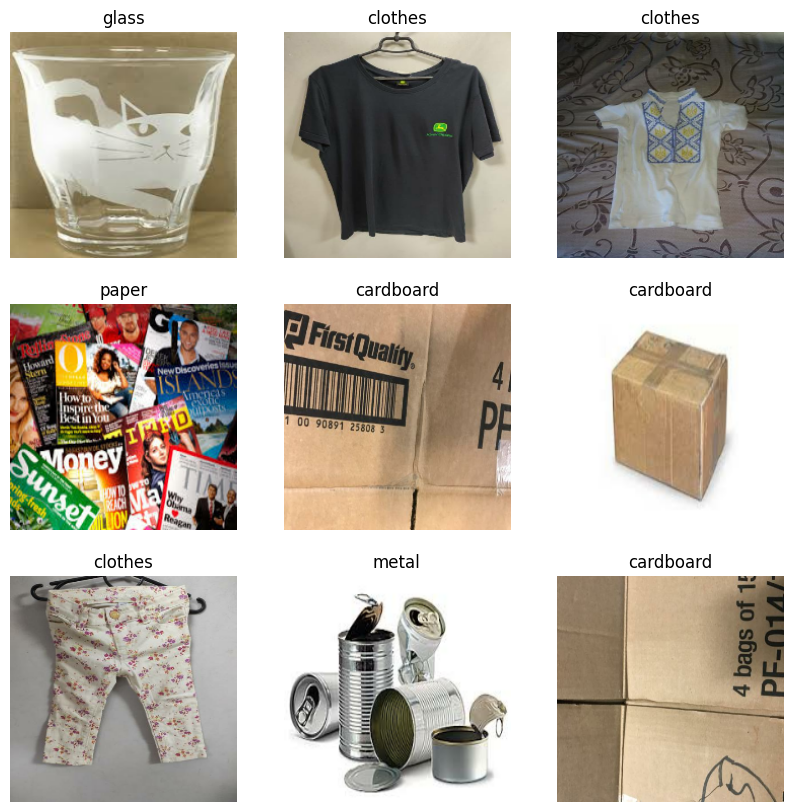

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [16]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


### Configure the dataset for performance

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(500).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

### Standardize the data

In [18]:
import tensorflow as tf
from tensorflow.keras import layers
normalization_layer = layers.Rescaling(1./255)

In [19]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.57062775 1.0


### Data Augmentation


In [20]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal",input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

])

/opt/homebrew/Caskroom/miniforge/base/envs/waste-classification/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Early Stopping

In [21]:
import keras

def get_early_stopping_callback(patience=5):

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1,
    )

    return [early_stop, reduce_lr]

### Model 2: ResNet50


In [ ]:
def build_resnet50(num_classes):

    base = tf.keras.applications.ResNet50(
        input_shape=(img_height, img_width, 3),
        include_top=False,
        weights="imagenet"
    )

    base.trainable = False
    
    inputs = keras.Input(shape=(img_height, img_width, 3))

    x = data_augmentation(inputs)
    x = tf.keras.applications.resnet50.preprocess_input(x)

    x = base(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)  

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)  

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.summary()

    return model

resnet50 = build_resnet50(num_classes)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │      1,290 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,147,466 (92.12 MB)

 Trainable params: 559,242 (2.13 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

### Compile Model

In [23]:
def compile_model(model):

    model.compile(
        optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
)

    return model

### Train Model

In [24]:
def train_model(model, train_ds, val_ds, epochs,patience=5):

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=get_early_stopping_callback(patience=patience),
       
    )

    return history

### Create plots of the loss and accuracy on the training and validation sets:

In [25]:
import matplotlib.pyplot as plt

def plot_history(history, title="Model Performance"):

    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')

    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # ---------------- Accuracy ----------------
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')

    # ---------------- Loss ----------------
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')

    plt.show()

### Train Resnet50

In [26]:
resnet50 = compile_model(resnet50)

resnet50_history = train_model(resnet50, train_ds, val_ds, 20, patience=5)

Epoch 1/20


2026-06-06 12:07:09.861074: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


388/388 ━━━━━━━━━━━━━━━━━━━━ 239s 595ms/step - accuracy: 0.7647 - loss: 0.7714 - val_accuracy: 0.9220 - val_loss: 0.2547 - learning_rate: 1.0000e-04
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 228s 574ms/step - accuracy: 0.8909 - loss: 0.3587 - val_accuracy: 0.9452 - val_loss: 0.1982 - learning_rate: 1.0000e-04
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 228s 572ms/step - accuracy: 0.9076 - loss: 0.2915 - val_accuracy: 0.9497 - val_loss: 0.1736 - learning_rate: 1.0000e-04
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 227s 569ms/step - accuracy: 0.9198 - loss: 0.2544 - val_accuracy: 0.9510 - val_loss: 0.1601 - learning_rate: 1.0000e-04
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 237s 592ms/step - accuracy: 0.9255 - loss: 0.2287 - val_accuracy: 0.9539 - val_loss: 0.1555 - learning_rate: 1.0000e-04
Epoch 6/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 228s 573ms/step - accuracy: 0.9232 - loss: 0.2275 - val_accuracy: 0.9552 - val_loss: 0.1527 - learning_rate: 1.0000e-04
Epoch 7/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 225s 565ms/

## Evaluation

In [27]:
val_loss, val_acc = resnet50.evaluate(val_ds)
print(val_acc)

97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 413ms/step - accuracy: 0.9629 - loss: 0.1207
0.9629390835762024


### Visualize training results: ResNet50


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])
[0.7646632194519043, 0.8909119963645935, 0.9075894355773926, 0.9197551012039185, 0.9254753589630127, 0.9232194423675537, 0.9351434111595154, 0.9374798536300659, 0.9417499303817749, 0.9445697665214539, 0.9431195855140686, 0.9490009546279907, 0.9479535818099976, 0.9478729963302612, 0.9488398432731628, 0.9502900242805481, 0.9529487490653992, 0.9513373970985413, 0.9546406865119934, 0.9577828049659729]
[0.9220109581947327, 0.9452143311500549, 0.9497260451316833, 0.9510151743888855, 0.953915536403656, 0.9552046656608582, 0.9542378187179565, 0.9581050872802734, 0.9597163796424866, 0.9587495923042297, 0.9613277316093445, 0.9619722962379456, 0.9574605226516724, 0.9626168012619019, 0.9629390835762024, 0.9593941569328308, 0.9622945785522461, 0.9626168012619019, 0.961650013923645, 0.9629390835762024]


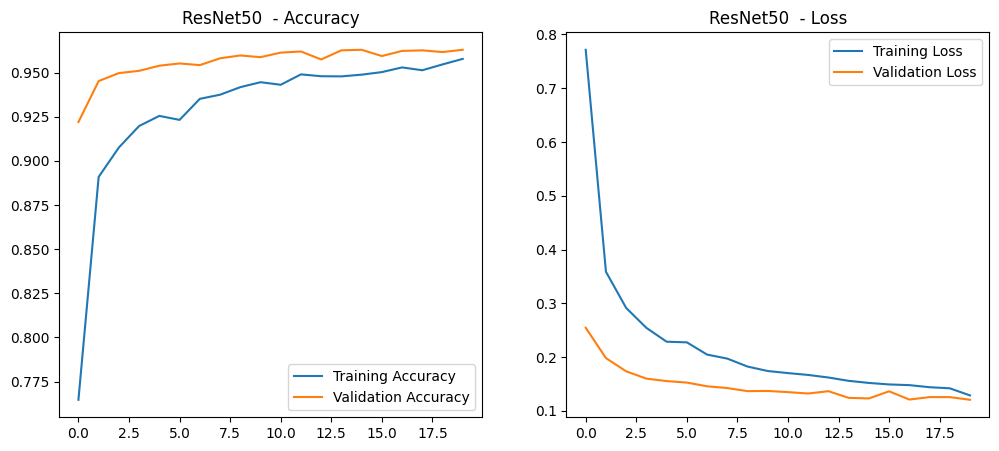

In [28]:
print(resnet50_history.history.keys())
print(resnet50_history.history['accuracy'])
print(resnet50_history.history['val_accuracy'])
plot_history(resnet50_history, "ResNet50 ")

### Confusion Matrix: Resnet50

              precision    recall  f1-score   support

     battery       0.98      0.97      0.98       187
  biological       0.97      0.99      0.98       200
   cardboard       0.97      0.94      0.95       178
     clothes       0.99      0.99      0.99      1084
       glass       0.94      0.96      0.95       402
       metal       0.86      0.95      0.90       148
       paper       0.95      0.95      0.95       217
     plastic       0.93      0.83      0.88       169
       shoes       0.97      0.97      0.97       392
       trash       0.97      0.93      0.95       126

    accuracy                           0.96      3103
   macro avg       0.95      0.95      0.95      3103
weighted avg       0.96      0.96      0.96      3103



2026-06-06 13:19:07.059426: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


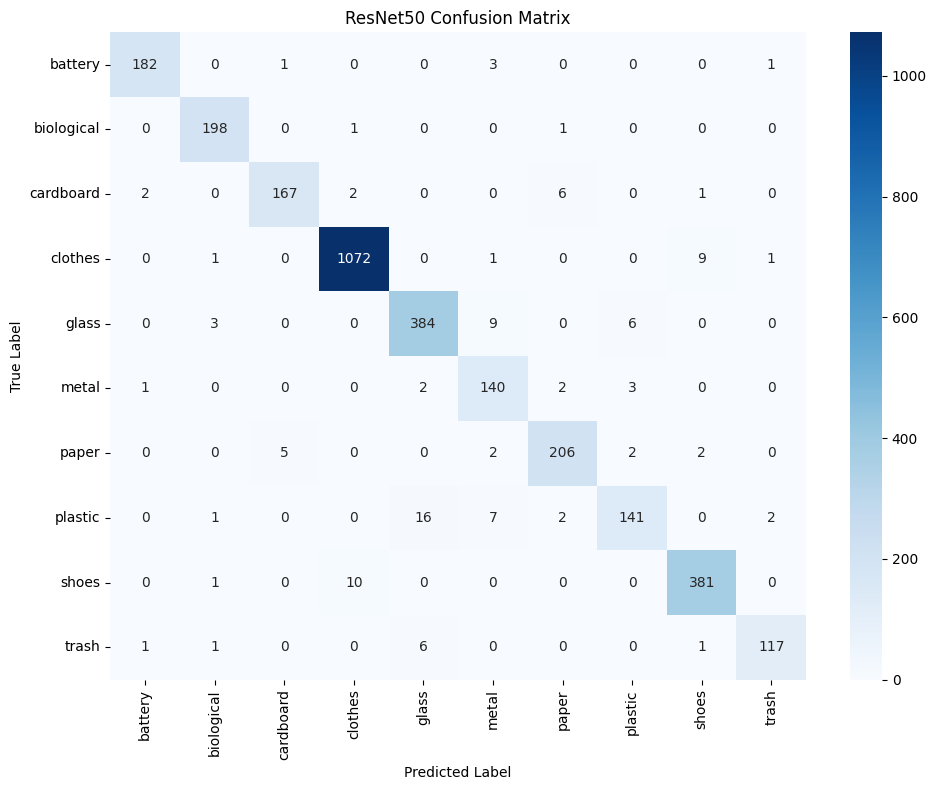

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = resnet50.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ResNet50 Confusion Matrix')
plt.tight_layout()
plt.show()


In [30]:
import cv2
image_folder = 'test_images/' 
print(class_names)
if os.path.exists(image_folder):
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for img_name in image_files:
        img_path = os.path.join(image_folder, img_name)
        img_array = cv2.imread(img_path)
        img_array = cv2.resize(img_array, (img_width, img_height))
        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
        
        img_array = np.expand_dims(img_array, axis=0)         
        predictions = resnet50.predict(img_array, verbose=0)
        
        print(f"Image Name: {img_name}")
        print("This image most likely belongs to {} with a {:.2f} percent confidence."
              .format(class_names[np.argmax(predictions)], 100 * np.max(predictions)))
        print("-" * 60)

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Image Name: test_metal_3.jpeg
This image most likely belongs to metal with a 99.77 percent confidence.
------------------------------------------------------------
Image Name: test_cloth_1.jpeg
This image most likely belongs to clothes with a 91.08 percent confidence.
------------------------------------------------------------
Image Name: test_metal_4.jpg
This image most likely belongs to metal with a 99.99 percent confidence.
------------------------------------------------------------
Image Name: test_plastic_1.jpeg
This image most likely belongs to plastic with a 99.99 percent confidence.
------------------------------------------------------------
Image Name: test_bio_1.jpg
This image most likely belongs to biological with a 100.00 percent confidence.
------------------------------------------------------------
Image Name: test_greenglass_1.jpeg
This image most likely belongs 

In [31]:
resnet50.save("resnet50_waste_classifier_v2.keras")